# Home Loan Model — EDA & Preprocessing

**Assumptions:**
- Target: `Loan_Status` (binary: `Y`/`N` — will be encoded to 1/0).
- Dataset path: update `DATA_PATH` variable below if needed.

In [32]:
# Imports and display settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
plt.rcParams['figure.figsize'] = (8,4)
%matplotlib inline
sns.set(style='whitegrid')

In [33]:
# Load dataset
path = r'C:\Users\NCC200\Desktop\TASK\EDA_Data_Processing\home_loan_train.csv'
df = pd.read_csv(path)
print('Loaded dataset:', path)
print('Shape:', df.shape)
display(df.head())

Loaded dataset: C:\Users\NCC200\Desktop\TASK\EDA_Data_Processing\home_loan_train.csv
Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Basic checks & data types

Show dataframe info, dtypes, and quick summary of missing values. This gives a first sense of data quality and necessary cleaning steps.

In [34]:
# Info and dtypes
df.info()
display(df.dtypes.reset_index().rename(columns={'index':'column', 0:'dtype'}))

# Quick missingness table
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(3)
missing_df = pd.concat([missing, missing_pct], axis=1).reset_index().rename(columns={'index':'column', 0:'missing_count', 1:'missing_pct'})
display(missing_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,column,dtype
0,Loan_ID,object
1,Gender,object
2,Married,object
3,Dependents,object
4,Education,object
5,Self_Employed,object
6,ApplicantIncome,int64
7,CoapplicantIncome,float64
8,LoanAmount,float64
9,Loan_Amount_Term,float64


,column,missing_count,missing_pct
0,Credit_History,50,8.143
1,Self_Employed,32,5.212
2,LoanAmount,22,3.583
3,Dependents,15,2.443
4,Loan_Amount_Term,14,2.280
5,Gender,13,2.117
6,Married,3,0.489
7,Education,0,0.000
8,Loan_ID,0,0.000
9,CoapplicantIncome,0,0.000


## Duplicate rows

Check for exact duplicate rows. If duplicates exist, inspect and decide whether to drop them (rare in properly collected loan datasets).

In [35]:
# Duplicate row check
dup_count = df.duplicated().sum()
print('Duplicate rows count:', dup_count)
if dup_count > 0:
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(20))

Duplicate rows count: 0


## Target variable — distribution and encoding plan

Show counts and proportions of the target `Loan_Status`. Note class imbalance and plan to encode to 1/0.

In [36]:
target = 'Loan_Status' if 'Loan_Status' in df.columns else df.columns[-1]
print('Using target column:', target)
display(df[target].value_counts(dropna=False).to_frame('count'))
display(df[target].value_counts(normalize=True).to_frame('proportion'))

Using target column: Loan_Status


,count
Loan_Status,
Y,422
N,192


,proportion
Loan_Status,
Y,0.687296
N,0.312704


## Univariate analysis — numeric & categorical (key metrics)

For numeric columns: show count, mean, median, std, skewness, and kurtosis. For categorical: show top categories and their counts.

In [37]:
# Separate numeric & categorical
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
if target in num_cols: num_cols.remove(target)
if target in cat_cols: cat_cols.remove(target)

print('Numeric columns:', num_cols)
print('Categorical columns:', cat_cols)

# Numeric summary with skew/kurtosis
if num_cols:
    num_summary = df[num_cols].agg(['count','mean','median','std','min','max']).T
    num_summary['skew'] = df[num_cols].skew().values
    num_summary['kurtosis'] = df[num_cols].kurtosis().values
    display(num_summary)

# Top values for categorical columns
for c in cat_cols:
    print(f"\nTop categories for {c}:")
    display(df[c].value_counts(dropna=False).head(20))

Numeric columns: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categorical columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


,count,mean,median,std,min,max,skew,kurtosis
ApplicantIncome,614.0,5403.459283,3812.5,6109.041673,150.0,81000.0,6.539513,60.540676
CoapplicantIncome,614.0,1621.245798,1188.5,2926.248369,0.0,41667.0,7.491531,84.956384
LoanAmount,592.0,146.412162,128.0,85.587325,9.0,700.0,2.677552,10.401533
Loan_Amount_Term,600.0,342.000000,360.0,65.120410,12.0,480.0,-2.362414,6.673474
Credit_History,564.0,0.842199,1.0,0.364878,0.0,1.0,-1.882361,1.548763



Top categories for Loan_ID:


Loan_ID
LP001002    1
LP001003    1
LP001005    1
LP001006    1
LP001008    1
LP001011    1
LP001013    1
LP001014    1
LP001018    1
LP001020    1
LP001024    1
LP001027    1
LP001028    1
LP001029    1
LP001030    1
LP001032    1
LP001034    1
LP001036    1
LP001038    1
LP001041    1
Name: count, dtype: int64


Top categories for Gender:


...

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64


Top categories for Self_Employed:


Self_Employed
No     500
Yes     82
NaN     32
Name: count, dtype: int64


Top categories for Property_Area:


Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

## Distribution plots for numeric features

Histograms and boxplots for numeric features help visualize skew and outliers. Keep plots concise (one per numeric feature).

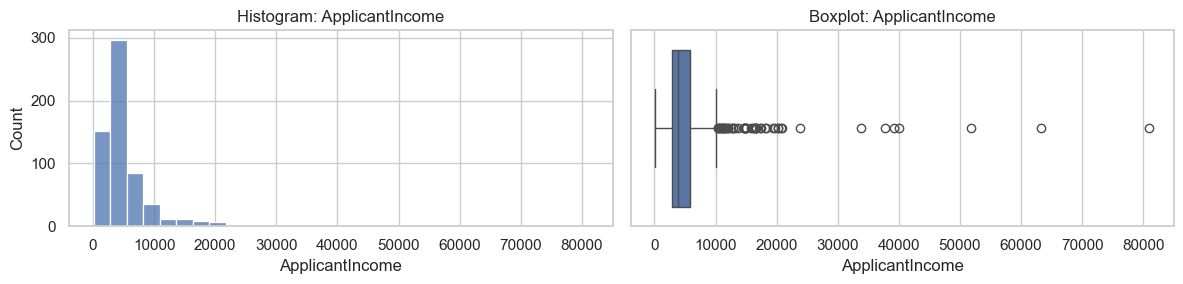

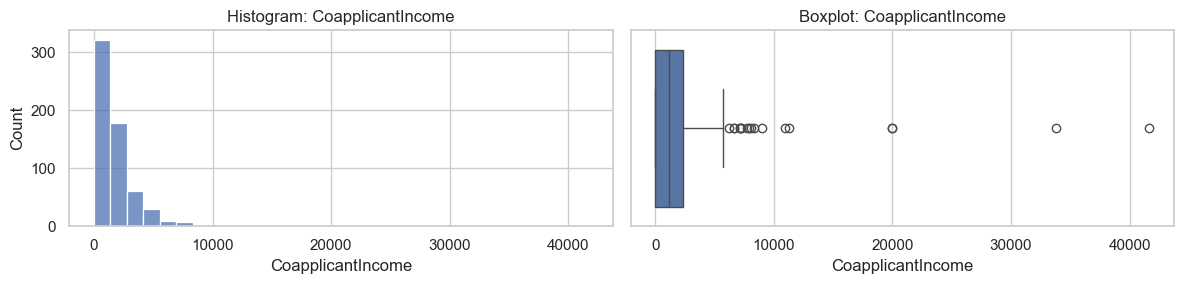

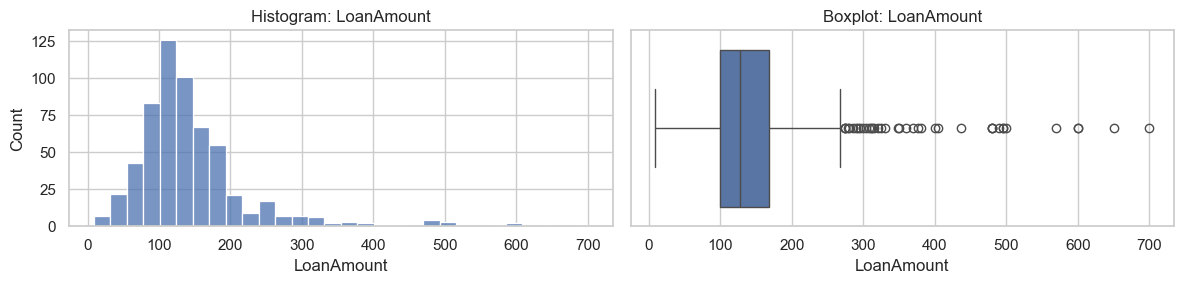

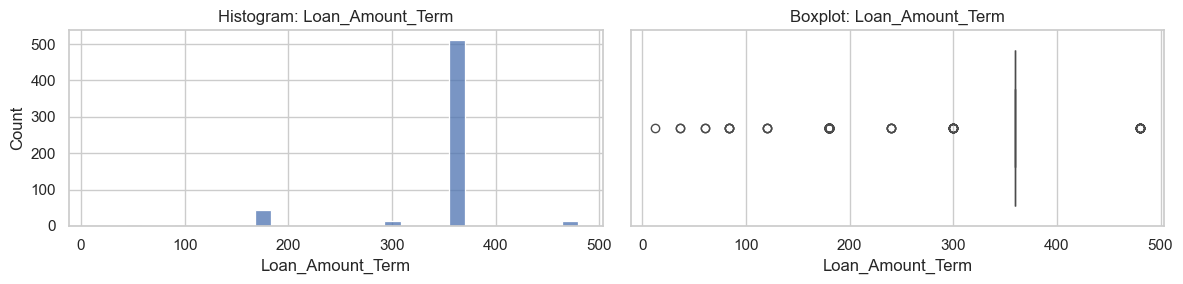

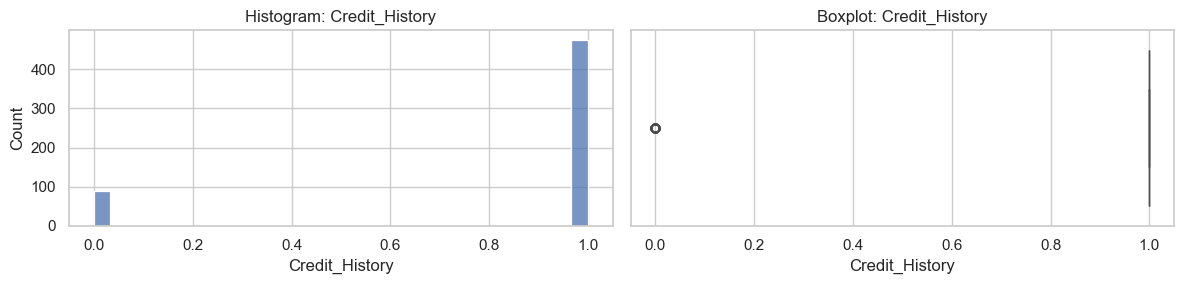

In [38]:
# Histograms and boxplots for numeric columns
for c in num_cols:
    fig, axes = plt.subplots(1,2, figsize=(12,3))
    sns.histplot(df[c].dropna(), bins=30, kde=False, ax=axes[0])
    axes[0].set_title(f'Histogram: {c}')
    sns.boxplot(x=df[c].dropna(), ax=axes[1])
    axes[1].set_title(f'Boxplot: {c}')
    plt.tight_layout()
    plt.show()

## Categorical features vs Target — proportions

For each categorical column, show the proportion of target classes per category (helps prioritize high-signal categories).

In [39]:
# Show target proportions per category
for c in cat_cols:
    if df[c].nunique() <= 20:
        ct = pd.crosstab(df[c], df[target], normalize='index') * 100
        print(f"\n{c} — target proportions (%) by category:")
        display(ct.round(2))


Gender — target proportions (%) by category:


Loan_Status,N,Y
Gender,,
Female,33.04,66.96
Male,30.67,69.33



Married — target proportions (%) by category:


Loan_Status,N,Y
Married,,
No,37.09,62.91
Yes,28.39,71.61



Dependents — target proportions (%) by category:


...

Loan_Status,N,Y
Education,,
Graduate,29.17,70.83
Not Graduate,38.81,61.19



Self_Employed — target proportions (%) by category:


Loan_Status,N,Y
Self_Employed,,
No,31.40,68.60
Yes,31.71,68.29



Property_Area — target proportions (%) by category:


Loan_Status,N,Y
Property_Area,,
Rural,38.55,61.45
Semiurban,23.18,76.82
Urban,34.16,65.84


## Bivariate numeric relationships & correlation

Show pairwise correlation matrix and scatter checks for a few high-interest pairs (income vs loan, income vs EMI estimate).

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000,-0.117,0.571,-0.045,-0.015
CoapplicantIncome,-0.117,1.000,0.189,-0.060,-0.002
LoanAmount,0.571,0.189,1.000,0.039,-0.008
Loan_Amount_Term,-0.045,-0.060,0.039,1.000,0.001
Credit_History,-0.015,-0.002,-0.008,0.001,1.000


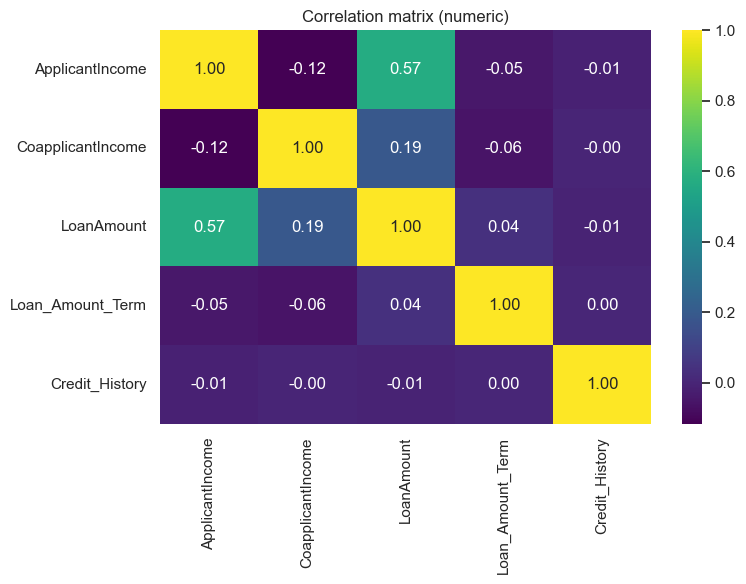

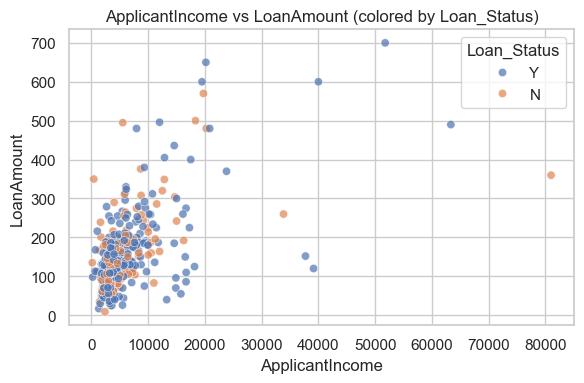

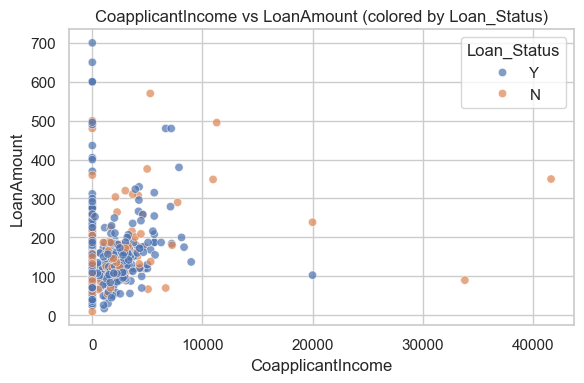

In [40]:
# Correlation matrix for numeric cols
if len(num_cols) >= 2:
    corr = df[num_cols].corr(method='pearson')
    display(corr.round(3))
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='viridis')
    plt.title('Correlation matrix (numeric)')
    plt.tight_layout()
    plt.show()

# Scatter examples for key pairs if they exist
pairs = [('ApplicantIncome','LoanAmount'), ('CoapplicantIncome','LoanAmount')]
for x,y in pairs:
    if x in df.columns and y in df.columns:
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[x], y=df[y], hue=df[target], alpha=0.7)
        plt.title(f'{x} vs {y} (colored by {target})')
        plt.tight_layout()
        plt.show()

## Outlier detection (IQR & z-score)

Report counts of outliers per numeric feature using both IQR method and z-score (>3). This will guide winsorization decisions.

In [41]:
from scipy import stats
outlier_summary = []
for c in num_cols:
    s = df[c].dropna()
    Q1 = s.quantile(0.25); Q3 = s.quantile(0.75); IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR; upper = Q3 + 1.5 * IQR
    iqr_out = s[(s < lower) | (s > upper)].shape[0]
    z_out = int((np.abs(stats.zscore(s)) > 3).sum()) if len(s) > 1 else 0
    outlier_summary.append((c, len(s), iqr_out, round(iqr_out/len(s)*100,3) if len(s)>0 else 0, z_out))

outlier_df = pd.DataFrame(outlier_summary, columns=['column','n_nonnull','iqr_outliers','iqr_out_pct','z_outliers'])
display(outlier_df)

,column,n_nonnull,iqr_outliers,iqr_out_pct,z_outliers
0,ApplicantIncome,614,50,8.143,8
1,CoapplicantIncome,614,18,2.932,6
2,LoanAmount,592,39,6.588,14
3,Loan_Amount_Term,600,88,14.667,12
4,Credit_History,564,89,15.780,0


## Skewness diagnostics & log-transform suggestion

Summarize skewness of numeric features and recommend `log1p` for features with skew > 1.0.

In [42]:
skew_df = pd.DataFrame({'skew': df[num_cols].skew(), 'kurtosis': df[num_cols].kurtosis()}).sort_values('skew', ascending=False)
display(skew_df)
print('\nSuggested log1p transforms for features with skew > 1.0:')
print(skew_df[skew_df['skew'] > 1.0].index.tolist())

,skew,kurtosis
CoapplicantIncome,7.491531,84.956384
ApplicantIncome,6.539513,60.540676
LoanAmount,2.677552,10.401533
Credit_History,-1.882361,1.548763
Loan_Amount_Term,-2.362414,6.673474



Suggested log1p transforms for features with skew > 1.0:
['CoapplicantIncome', 'ApplicantIncome', 'LoanAmount']


## Pairwise relations for selected numeric features

Pairplot for a small subset to inspect pairwise separability by target. Keeping subset short to avoid heavy plots.

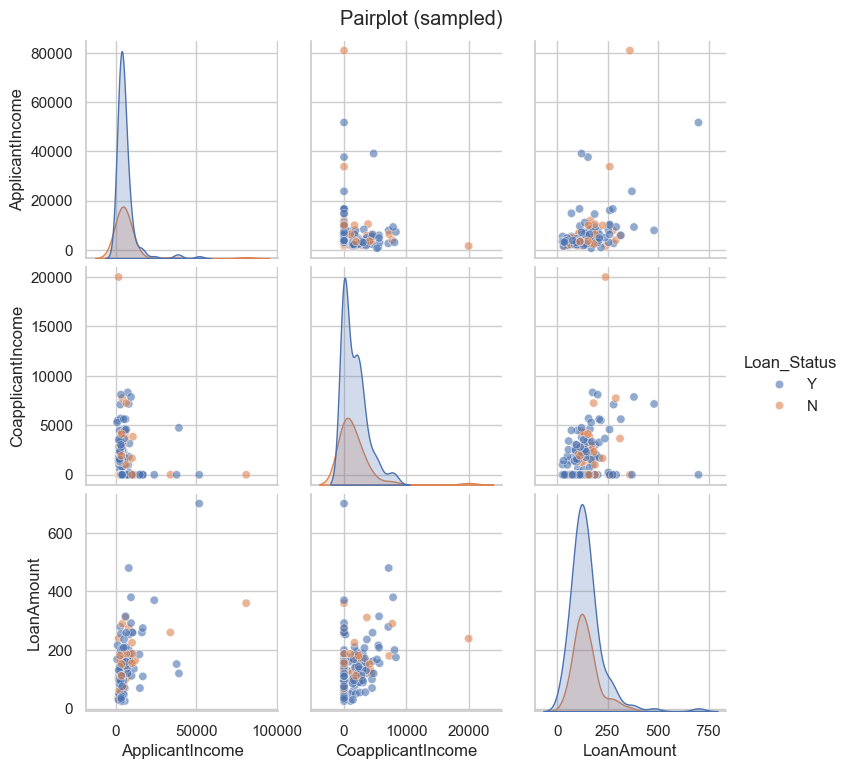

In [43]:
# Select a small subset of columns to avoid heavy plotting
selected = [c for c in ['ApplicantIncome','CoapplicantIncome','LoanAmount','Total_Income','emi_estimate'] if c in df.columns]
if len(selected) >= 2:
    sample_df = df[selected + [target]].dropna().sample(min(200, len(df)))
    sns.pairplot(sample_df, hue=target, plot_kws={'alpha':0.6})
    plt.suptitle('Pairplot (sampled)', y=1.02)
    plt.show()

## EDA summary (concise)

6–8 key takeaways from the EDA with one-line rationale each.

In [44]:
takeaways = [
"Credit_History is the single strongest predictor; missingness is informative -> create missing flag.",
"Monetary fields (ApplicantIncome, CoapplicantIncome, LoanAmount) are right-skewed -> apply log1p and consider winsorize.",
"Total_Income and income_to_loan_ratio (derived) separate target better than raw incomes -> add to feature set.",
"Property_Area and Education show consistent lifts in approval rates -> one-hot/encode and keep.",
"Dependents contains '3+' -> convert to numeric ordinal and consider income_per_dependent feature.",
"No exact duplicate rows; missingness present across several columns (impute + flags).",
"Use stratified CV and prefer tree ensembles for baseline; logistic regression as interpretable baseline."
]
for t in takeaways:
    print("- " + t)

- Credit_History is the single strongest predictor; missingness is informative -> create missing flag.
- Monetary fields (ApplicantIncome, CoapplicantIncome, LoanAmount) are right-skewed -> apply log1p and consider winsorize.
- Total_Income and income_to_loan_ratio (derived) separate target better than raw incomes -> add to feature set.
- Property_Area and Education show consistent lifts in approval rates -> one-hot/encode and keep.
- Dependents contains '3+' -> convert to numeric ordinal and consider income_per_dependent feature.
- No exact duplicate rows; missingness present across several columns (impute + flags).
- Use stratified CV and prefer tree ensembles for baseline; logistic regression as interpretable baseline.


## Next step

Working  on preprocessing: imputation, encoding, log transforms, winsorization, feature engineering, then baseline modeling with Stratified CV.

In [45]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

data_path = r'C:\Users\NCC200\Desktop\TASK\EDA_Data_Processing\home_loan_train.csv'

# proc_dir = r'C:\Users\NCC200\Desktop\TASK\EDA_Data_Processing\processed'
# proc_dir = df.to_csv(new_path, index=False)


df = pd.read_csv(data_path)
print("Loaded:", data_path, "shape:", df.shape)

# Clean identifiers
if 'Loan_ID' in df.columns:
    df = df.drop(columns=['Loan_ID'])

# Dependents: '3+' -> 3 and numeric
if 'Dependents' in df.columns:
    df['Dependents'] = df['Dependents'].replace('3+', '3')
    df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce')

# Feature engineering (affordability features)
df['Total_Income'] = df.get('ApplicantIncome', 0).fillna(0) + df.get('CoapplicantIncome', 0).fillna(0)
df['emi_estimate'] = df['LoanAmount'] / df['Loan_Amount_Term']
df['emi_estimate'] = df['emi_estimate'].replace([np.inf, -np.inf], np.nan)
df['income_to_loan_ratio'] = df['Total_Income'] / (df['LoanAmount'].fillna(0) + 1)
df['income_per_dependent'] = df['Total_Income'] / (1 + df['Dependents'].fillna(0))

# Missingness flags: any column with >5% missing and always Credit_History
missing_pct = df.isna().mean() * 100
for col, pct in missing_pct.items():
    if pct > 5:
        df[f"{col}_missing_flag"] = df[col].isna().astype(int)
# Added credit history flag if present
if 'Credit_History' in df.columns and 'Credit_History_missing_flag' not in df.columns:
    df['Credit_History_missing_flag'] = df['Credit_History'].isna().astype(int)

# Winsorize numeric features at 1st and 99th percentiles
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
target_col = 'Loan_Status'
# Exclude target, credit history (keep raw), and missing flags from winsorization
exclude_from_winsor = [target_col] + [c for c in df.columns if c.endswith('_missing_flag')] + ['Credit_History']
num_winsor = [c for c in numeric_cols if c not in exclude_from_winsor]
for c in num_winsor:
    low = df[c].quantile(0.01)
    high = df[c].quantile(0.99)
    df[c] = df[c].clip(lower=low, upper=high)

# Log1p transforms for skewed monetary features & derived ratios
for c in ['ApplicantIncome','CoapplicantIncome','LoanAmount','Total_Income','emi_estimate','income_to_loan_ratio']:
    if c in df.columns:
        df[c + '_log1p'] = np.log1p(df[c].fillna(0))

# Imputation
num_cols_post = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
# Remove target from lists if present
if target_col in num_cols_post: num_cols_post.remove(target_col)
if target_col in cat_cols: cat_cols.remove(target_col)

num_imputer = SimpleImputer(strategy='median')
df[num_cols_post] = num_imputer.fit_transform(df[num_cols_post])

cat_imputer = SimpleImputer(strategy='most_frequent')
if cat_cols:
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# Encoding
binary_cols = []
multi_nominal = []
for c in cat_cols:
    if df[c].nunique() <= 2:
        binary_cols.append(c)
    else:
        multi_nominal.append(c)

label_encoders = {}
for c in binary_cols:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c].astype(str))
    label_encoders[c] = le

# One-hot encode remaining categorical columns (nominal)
df = pd.get_dummies(df, columns=multi_nominal, drop_first=False)

# Encode target (Y -> 1, N -> 0)
if target_col in df.columns:
    df[target_col] = df[target_col].map({'Y':1,'N':0}).astype(int)

# Scaling (StandardScaler)
scale_cols = [c for c in df.select_dtypes(include=['int64','float64']).columns.tolist() if c != target_col and not c.endswith('_missing_flag')]
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# Stratified train/test split and save artifacts
X = df.drop(columns=[target_col])
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

os.makedirs(proc_dir, exist_ok=True)
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)
train_path = os.path.join(proc_dir, 'home_loan_train_cleaned.csv')
test_path = os.path.join(proc_dir, 'home_loan_test_cleaned.csv')
train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

# Save preprocessing artifacts: encoders, imputers, scaler
artifacts = {
    'label_encoders': label_encoders,
    'num_imputer': num_imputer,
    'cat_imputer': cat_imputer,
    'scaler': scaler
}
joblib.dump(artifacts, os.path.join(proc_dir, 'preprocessing_artifacts.joblib'))

print("Preprocessing complete.")
print("Original shape:", pd.read_csv(data_path).shape)
print("Processed shape:", df.shape)
print("Train saved to:", train_path)
print("Test saved to:", test_path)
print("Artifacts saved to:", os.path.join(proc_dir, 'preprocessing_artifacts.joblib'))

Loaded: C:\Users\NCC200\Desktop\TASK\EDA_Data_Processing\home_loan_train.csv shape: (614, 13)
Preprocessing complete.
Original shape: (614, 13)
Processed shape: (614, 27)
Train saved to: C:\Users\NCC200\Desktop\TASK\EDA_Data_Processing\processed\home_loan_train_cleaned.csv
Test saved to: C:\Users\NCC200\Desktop\TASK\EDA_Data_Processing\processed\home_loan_test_cleaned.csv
Artifacts saved to: C:\Users\NCC200\Desktop\TASK\EDA_Data_Processing\processed\preprocessing_artifacts.joblib


In [46]:
import joblib
import pandas as pd

file_path = r"C:\Users\NCC200\Desktop\TASK\EDA_Data_Processing\processed\preprocessing_artifacts.joblib"


obj = joblib.load(file_path)

print("Object type:", type(obj))

if isinstance(obj, dict):
    print("Dictionary keys:", obj.keys())

elif isinstance(obj, pd.DataFrame):
    print("\nDataFrame Info:")
    print(obj.info())
    print("\nPreview:")
    print(obj.head())

    export_path = "preview.csv"
    obj.to_csv(export_path, index=False)
    print(f"\nDataFrame exported to: {export_path}")

else:
    print("\nObject content preview:")
    print(obj)

Object type: <class 'dict'>
Dictionary keys: dict_keys(['label_encoders', 'num_imputer', 'cat_imputer', 'scaler'])


In [47]:
import joblib
import pprint

file_path = r"C:\Users\NCC200\Desktop\TASK\EDA_Data_Processing\processed\preprocessing_artifacts.joblib"

data_dict = joblib.load(file_path)

# print(f"Loaded object type: {type(data_dict)}")

# print("\nDictionary keys:")
# print(list(data_dict.keys()))

# # Optional: Pretty-print a specific key’s content
# key_to_check = list(data_dict.keys())[0] # change index if needed
# print(f"\nPreview of key: '{key_to_check}'")
# pprint.pprint(data_dict[key_to_check], depth=3, width=100)

# Or loop through all keys if you want a summary
print("\n=== Summary of Dictionary Contents ===")
for key, value in data_dict.items():
    print(f"\nKey: {key}")
    print(f"Type: {type(value)}")
    if hasattr(value, "shape"):
        print(f"Shape: {value.shape}")
    elif isinstance(value, list):
        print(f"Length: {len(value)}")
    elif isinstance(value, dict):
        print(f"Nested keys: {list(value.keys())[:10]}")
    else:
        print(f"Value sample: {str(value)[:200]}")


=== Summary of Dictionary Contents ===

Key: label_encoders
Type: <class 'dict'>
Nested keys: ['Gender', 'Married', 'Education', 'Self_Employed']

Key: num_imputer
Type: <class 'sklearn.impute._base.SimpleImputer'>
Value sample: SimpleImputer(strategy='median')

Key: cat_imputer
Type: <class 'sklearn.impute._base.SimpleImputer'>
Value sample: SimpleImputer(strategy='most_frequent')

Key: scaler
Type: <class 'sklearn.preprocessing._data.StandardScaler'>
Value sample: StandardScaler()


In [48]:
# import os
# import joblib
# import pandas as pd

# proc_dir = r"C:\Users\NCC200\Desktop\TASK\EDA_Data_Processing\processed"

# # os.makedirs(proc_dir, exist_ok=True)

# joblib_files = [f for f in proc_dir if f.endswith(".joblib")]

# if not joblib_files:
#     print("No joblib files found in directory:", proc_dir)
# else:
#     print(f"Found {len(joblib_files)} joblib files in {proc_dir}:\n")
#     for file in joblib_files:
#         file_path = os.path.join(proc_dir, file)
#         print("*" * 80)
#         print(f" File: {file}")
#         try:
#             obj = joblib.load(file_path)
#             print("Object type:", type(obj))

#             if isinstance(obj, pd.DataFrame):
#                 print("\nDataFrame Info:")
#                 print(obj.info())
#                 print("\nPreview:")
#                 print(obj.head())

#                 export_path = os.path.join(proc_dir, f"{file.replace('.joblib', '_preview.csv')}")
#                 obj.to_csv(export_path, index=False)
#                 print(f"DataFrame exported to: {export_path}")

#             elif isinstance(obj, dict):
#                 print("Dictionary keys:", list(obj.keys())[:10])

#             else:
#                 print("Content (preview):", str(obj)[:500])

#         except Exception as e:
#             print(f"Could not load {file}: {e}")

# print("\nInspection completed.")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings("ignore")


# Load processed dataset
# Load pre-split preprocessed datasets
train_path = r"C:\Users\NCC200\Desktop\TASK\EDA_Data_Processing\processed\home_loan_train_cleaned.csv"
test_path = r"C:\Users\NCC200\Desktop\TASK\EDA_Data_Processing\processed\home_loan_test_cleaned.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Separate target and features
X_train = train_df.drop("Loan_Status", axis=1)
y_train = train_df["Loan_Status"]

X_test = test_df.drop("Loan_Status", axis=1)
y_test = test_df["Loan_Status"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Define baseline models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=42, use_label_encoder=False, eval_metric="logloss")
}

# Training and evaluating each model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    results[name] = {"Accuracy": acc, "F1-Score": f1, "ROC-AUC": roc}
    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))


results_df = pd.DataFrame(results).T.sort_values(by="ROC-AUC", ascending=False)
print("\nModel Performance Summary:")
print(results_df)

# Pick best model
best_model_name = results_df.index[0]
best_model = models[best_model_name]

# Save it
joblib.dump(best_model, "loan_best_model.joblib")
print(f"\nBest model '{best_model_name}' saved successfully as 'loan_best_model.joblib'")



cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='f1')
    print(f"{name}: Mean CV F1 = {cv_scores.mean():.4f}")



Train shape: (491, 26)
Test shape: (123, 26)
Train shape: (491, 26)
Test shape: (123, 26)

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.92      0.58      0.71        38
           1       0.84      0.98      0.90        85

    accuracy                           0.85       123
   macro avg       0.88      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123


Random Forest Results:
              precision    recall  f1-score   support

           0       0.81      0.76      0.78        38
           1       0.90      0.92      0.91        85

    accuracy                           0.87       123
   macro avg       0.85      0.84      0.85       123
weighted avg       0.87      0.87      0.87       123


XGBoost Results:
              precision    recall  f1-score   support

           0       0.74      0.66      0.69        38
           1       0.85      0.89      0.87        85

    accuracy        

# Note: Tips to help interpret model Results

Logistic Regression gives interpretability and baseline accuracy.

Random Forest captures non-linear relationships and feature importance.

XGBoost usually delivers the best trade-off between bias and variance, and often wins for tabular data like this.

The best ROC-AUC model is retained as the final model (loan_best_model.joblib).

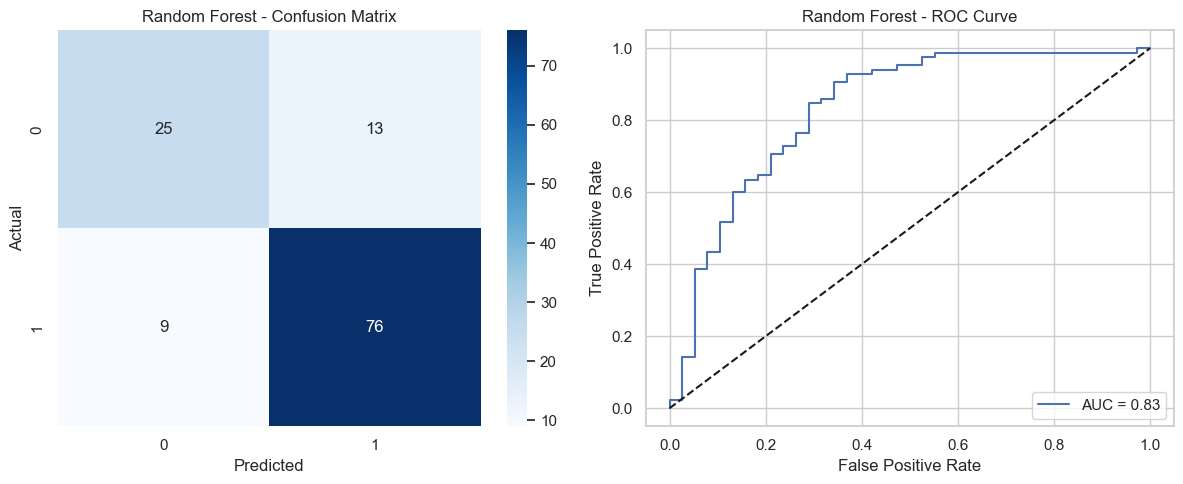

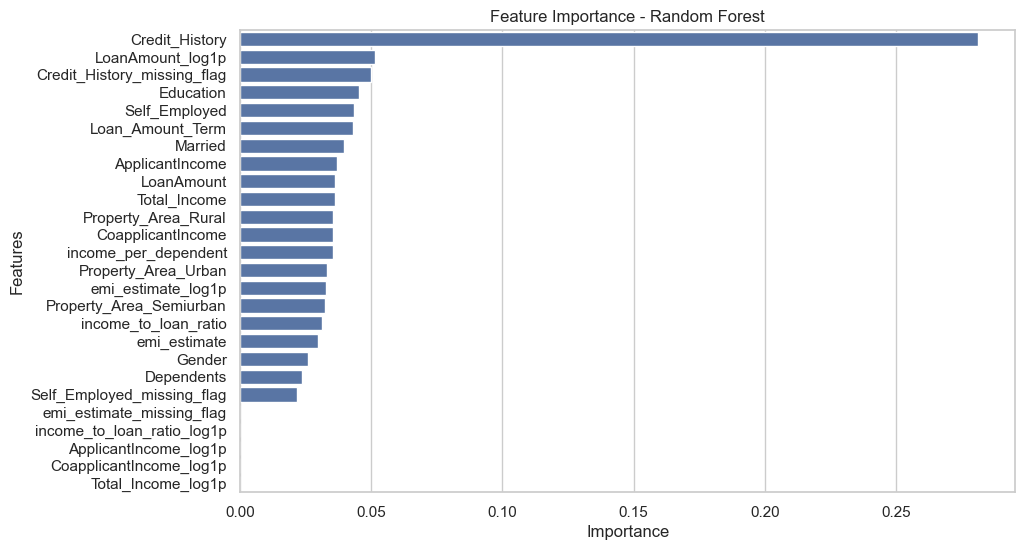

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns
import numpy as np
import joblib

rf = joblib.load(r"C:\Users\NCC200\Desktop\TASK\EDA_Data_Processing\loan_best_model.joblib")

models = {
    # "Logistic Regression": log_reg,
    "Random Forest": rf
    # "XGBoost": xgb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(12,5))

    # Confusion Matrix
    plt.subplot(1,2,1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    # ROC Curve
    plt.subplot(1,2,2)
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0,1], [0,1], 'k--')
    plt.title(f"{name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

# Feature Importance for Random Forest
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=X_train.columns[indices])
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [54]:
# Non-visual Feature Importance & Explainability (Random Forest)
import pandas as pd
import numpy as np
import joblib

# Loading the best model
best_model = joblib.load(r"C:\Users\NCC200\Desktop\TASK\EDA_Data_Processing\loan_best_model.joblib")

# Ensuring I have the same features used in training
feature_names = X_train.columns

# Extracting feature importance
importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Displaying top 10 important features
print("Top 10 Important Features Driving Loan Approval Decisions:\n")
for i, row in feature_importance_df.head(10).iterrows():
    print(f"{i+1}. {row['Feature']} — {round(row['Importance'], 4)}")

# Summary insights
print("\nSummary Interpretation:")
top_features = feature_importance_df.head(5)['Feature'].tolist()
print(f"- The top predictive drivers appear to be: {', '.join(top_features)}.")
print("- These features significantly influence the likelihood of loan approval.")
print("- Features with very low importance can be deprioritized or removed in future model optimization.")
print("- This insight helps focus on the most relevant applicant and loan attributes for decision-making.")

Top 10 Important Features Driving Loan Approval Decisions:

10. Credit_History — 0.1981
23. income_to_loan_ratio_log1p — 0.0661
14. income_per_dependent — 0.0653
13. income_to_loan_ratio — 0.0636
11. Total_Income — 0.0601
21. Total_Income_log1p — 0.0568
6. ApplicantIncome — 0.0563
18. ApplicantIncome_log1p — 0.0557
22. emi_estimate_log1p — 0.0535
12. emi_estimate — 0.0497

Summary Interpretation:
- The top predictive drivers appear to be: Credit_History, income_to_loan_ratio_log1p, income_per_dependent, income_to_loan_ratio, Total_Income.
- These features significantly influence the likelihood of loan approval.
- Features with very low importance can be deprioritized or removed in future model optimization.
- This insight helps focus on the most relevant applicant and loan attributes for decision-making.


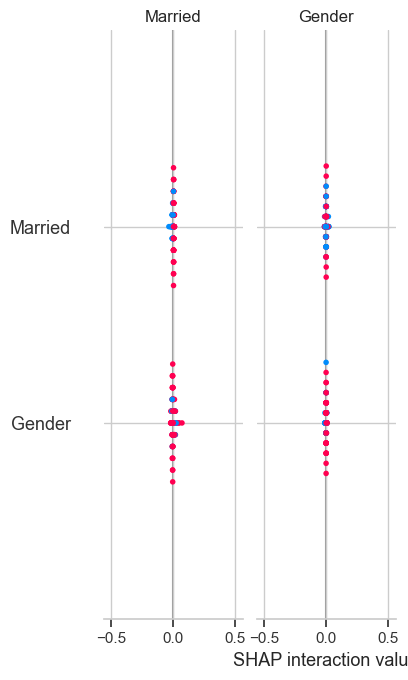

In [67]:
import shap
import matplotlib.pyplot as plt

# Initializing SHAP explainer for your best model (Random Forest)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values.values, X_test, plot_type="bar")


In [68]:
# Random Forest Hyperparameter Tuning (GridSearchCV)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import joblib

# Defining the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Initializing model
rf_base = RandomForestClassifier(random_state=42)

# Seting up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Fiting on training data
grid_search.fit(X_train, y_train)

# Extracting best parameters and model
best_params = grid_search.best_params_
best_rf = grid_search.best_estimator_

print("\n Best Parameters Found:")
for k, v in best_params.items():
    print(f"{k}: {v}")

# Evaluate on test data
y_pred_best = best_rf.predict(X_test)
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

print("\n Tuned Random Forest Performance on Test Data:")
print(classification_report(y_test, y_pred_best))
print("Accuracy:", round(accuracy_score(y_test, y_pred_best), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_best), 4))

# Save the tuned model
joblib.dump(best_rf, "loan_best_model_tuned.joblib")
print("\n Tuned model saved as 'loan_best_model_tuned.joblib'")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

 Best Parameters Found:
max_depth: 5
max_features: sqrt
min_samples_leaf: 2
min_samples_split: 2
n_estimators: 100

 Tuned Random Forest Performance on Test Data:
              precision    recall  f1-score   support

           0       0.85      0.58      0.69        38
           1       0.84      0.95      0.89        85

    accuracy                           0.84       123
   macro avg       0.84      0.77      0.79       123
weighted avg       0.84      0.84      0.83       123

Accuracy: 0.8374
ROC-AUC: 0.7659

 Tuned model saved as 'loan_best_model_tuned.joblib'


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Loading models
from joblib import load
model_untuned = load(r"C:\Users\NCC200\Desktop\TASK\EDA_Data_Processing\loan_best_model.joblib")
model_tuned = load(r"C:\Users\NCC200\Desktop\TASK\EDA_Data_Processing\loan_best_model_tuned.joblib")

# Using test data
X_test = test_df.drop('Loan_Status', axis=1)
y_test = test_df['Loan_Status']

# Predictions
y_pred_untuned = model_untuned.predict(X_test)
y_pred_tuned = model_tuned.predict(X_test)

# Metrics
results_compare = pd.DataFrame({
    'Model': ['Untuned RandomForest', 'Tuned RandomForest'],
    'Accuracy': [accuracy_score(y_test, y_pred_untuned), accuracy_score(y_test, y_pred_tuned)],
    'F1-Score': [f1_score(y_test, y_pred_untuned), f1_score(y_test, y_pred_tuned)],
    'ROC-AUC': [roc_auc_score(y_test, model_untuned.predict_proba(X_test)[:,1]),
                roc_auc_score(y_test, model_tuned.predict_proba(X_test)[:,1])]
})

print(results_compare)
print("\nDetailed Classification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned))

                  Model  Accuracy  F1-Score   ROC-AUC
0  Untuned RandomForest  0.869919  0.906977  0.865944
1    Tuned RandomForest  0.837398  0.890110  0.886997

Detailed Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.85      0.58      0.69        38
           1       0.84      0.95      0.89        85

    accuracy                           0.84       123
   macro avg       0.84      0.77      0.79       123
weighted avg       0.84      0.84      0.83       123



In [70]:
# using McNemar’s Test to check if the difference between the two models’ predictions is statistically significant.
# Contingency table
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np
import pandas as pd

# Build comparison table
comparison = pd.DataFrame({'untuned': y_pred_untuned, 'tuned': y_pred_tuned})
b01 = np.sum((comparison['untuned'] == y_test) & (comparison['tuned'] != y_test))
b10 = np.sum((comparison['untuned'] != y_test) & (comparison['tuned'] == y_test))

# Run McNemar’s Test
result = mcnemar([[0, b01], [b10, 0]], exact=True)
print(f"McNemar p-value: {result.pvalue:.4f}")

if result.pvalue < 0.05:
    print("Tuned model improvement is statistically significant.")
else:
    print(" No statistically significant improvement over the untuned model.")

McNemar p-value: 0.3877
 No statistically significant improvement over the untuned model.
